In [49]:
from pathlib import Path
import sys

# 获取项目根目录（ZZB）
PROJECT_ROOT = Path.cwd().parent

# 加入 Python 搜索路径
sys.path.append(str(PROJECT_ROOT))

In [50]:
from Src.waveform import generate_lfm

from Src.signal_matrix import build_signal_matrix

from Src.gram import gram_matrix

from Src.covariance import covariance_matrix

from Src.config import FS, T, B

In [51]:
import numpy as np
import matplotlib.pyplot as plt

In [52]:
K = 3

taus = np.sort(

    np.random.randint(
        20,
        320,
        size=K
    )

)

print(taus)

[ 38 139 182]


In [53]:
t,s=generate_lfm(FS, T, B)

In [54]:
S = build_signal_matrix(
    s,
    taus
)

In [55]:
G = gram_matrix(S)

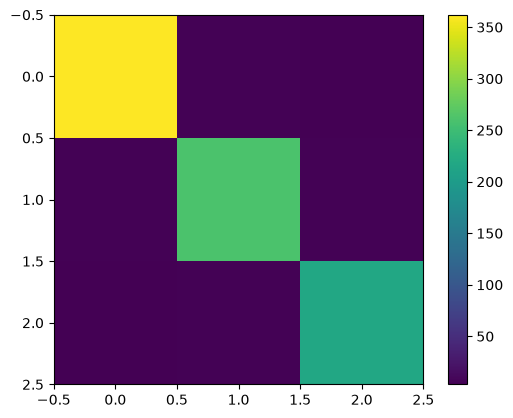

In [56]:
plt.imshow(
    np.abs(G)
)

plt.colorbar()

In [57]:
k = 1

h = 8

taus_shift = taus.copy()

taus_shift[k] += h

In [58]:
S_shift = build_signal_matrix(
    s,
    taus_shift
)
G_shift = gram_matrix(
    S_shift
)

In [59]:
columns = []

for i in range(K):

    if i != k:

        columns.append(
            S[:, i]
        )

columns.append(
    S[:, k]
)

columns.append(
    S_shift[:, k]
)

U = np.column_stack(columns)

In [60]:
print(U.shape)

(400, 4)


In [61]:
diag = np.ones(K+1)

diag[-2:] = 0.5

C = np.diag(diag)

sqrtC = np.sqrt(C)

Gav = sqrtC @ U.conj().T @ U @ sqrtC